In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nifty-50-minute-data/NIFTY AUTO_daily_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY ALPHA 50_minute_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY COMMODITIES_daily_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY INDIA MFG_daily_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY BANK_minute_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY 100_daily_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY IND DIGITAL_minute_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY FMCG_minute_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY FMCG_daily_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY 200_daily_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY INFRA_daily_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY 100_minute_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY CONSR DURBL_daily_data.csv
/kaggle/input/nifty-50-minute-data/NIFTY CONSUMPTION_daily_data.csv
/kaggle/input/nifty-50-minute-data/INDIA VIX_minute.csv
/kaggle/input/nifty-50-minute-data/NIFTY LARGEMID2

In [2]:
df_nifty50=pd.read_csv('/kaggle/input/nifty-50-minute-data/NIFTY 50_daily_data.csv')

In [3]:
df_nifty50

,date,open,high,low,close,volume
0,2015-01-01 00:00:00,8272.79,8294.70,8248.75,8284.00,0
1,2015-01-02 00:00:00,8288.70,8410.60,8288.70,8395.40,0
2,2015-01-05 00:00:00,8407.95,8445.60,8363.90,8378.40,0
3,2015-01-06 00:00:00,8325.29,8327.85,8111.35,8127.30,0
4,2015-01-07 00:00:00,8118.65,8151.20,8065.45,8102.10,0
...,...,...,...,...,...,...
2501,2025-02-03 00:00:00,23319.35,23381.60,23222.00,23361.05,0
2502,2025-02-04 00:00:00,23509.90,23762.75,23423.15,23739.25,0
2503,2025-02-05 00:00:00,23801.75,23807.30,23680.45,23696.30,0
2504,2025-02-06 00:00:00,23761.95,23773.55,23556.25,23603.35,0


In [4]:
def calculate_rsi(df, period=14):
    """
    Calculates the RSI for a given OHLC DataFrame.

    Args:
        df (pd.DataFrame): Pandas DataFrame with OHLC data (Open, High, Low, Close).
        period (int): RSI calculation period (default: 14).

    Returns:
        pd.DataFrame: DataFrame with RSI calculated.
    """
    # Calculate price changes
    price_change = df['close'].diff()

    # Calculate gains and losses
    gains = price_change.clip(lower=0)
    losses = -price_change.clip(upper=0)

    # Calculate average gain and loss
    avg_gain = gains.rolling(window=period).mean()
    avg_loss = losses.rolling(window=period).mean()

    # Calculate Relative Strength
    rs = avg_gain / avg_loss

    # Calculate RSI
    rsi = 100 - (100 / (1 + rs))

    # Add RSI to the DataFrame
    df['RSI'] = rsi

    return df

In [5]:
calculate_rsi(df_nifty50,14)

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,date,open,high,low,close,volume,RSI
0,2015-01-01 00:00:00,8272.79,8294.70,8248.75,8284.00,0,NaN
1,2015-01-02 00:00:00,8288.70,8410.60,8288.70,8395.40,0,NaN
2,2015-01-05 00:00:00,8407.95,8445.60,8363.90,8378.40,0,NaN
3,2015-01-06 00:00:00,8325.29,8327.85,8111.35,8127.30,0,NaN
4,2015-01-07 00:00:00,8118.65,8151.20,8065.45,8102.10,0,NaN
...,...,...,...,...,...,...,...
2501,2025-02-03 00:00:00,23319.35,23381.60,23222.00,23361.05,0,53.601968
2502,2025-02-04 00:00:00,23509.90,23762.75,23423.15,23739.25,0,59.165076
2503,2025-02-05 00:00:00,23801.75,23807.30,23680.45,23696.30,0,60.878966
2504,2025-02-06 00:00:00,23761.95,23773.55,23556.25,23603.35,0,55.830365


In [6]:
df_nifty50.isna().sum()

date       0
open       0
high       0
low        0
close      0
volume     0
RSI       14
dtype: int64

In [7]:
df_nifty50.dropna(inplace= True)

In [8]:
df_nifty50.isna().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
RSI       0
dtype: int64

In [9]:
df_nifty50['EMA21'] = df_nifty50['close'].ewm(span=21, adjust=False).mean()

In [10]:
df_nifty50

,date,open,high,low,close,volume,RSI,EMA21
14,2015-01-21 00:00:00,8719.65,8741.85,8689.60,8729.50,0,69.833497,8729.500000
15,2015-01-22 00:00:00,8745.85,8774.15,8727.00,8761.40,0,67.535454,8732.400000
16,2015-01-23 00:00:00,8827.95,8866.40,8795.40,8835.60,0,70.766715,8741.781818
17,2015-01-27 00:00:00,8871.35,8925.04,8825.45,8910.50,0,92.353450,8757.119835
18,2015-01-28 00:00:00,8902.75,8985.04,8874.04,8914.29,0,94.962300,8771.408032
...,...,...,...,...,...,...,...,...
2501,2025-02-03 00:00:00,23319.35,23381.60,23222.00,23361.05,0,53.601968,23352.144934
2502,2025-02-04 00:00:00,23509.90,23762.75,23423.15,23739.25,0,59.165076,23387.336304
2503,2025-02-05 00:00:00,23801.75,23807.30,23680.45,23696.30,0,60.878966,23415.423913
2504,2025-02-06 00:00:00,23761.95,23773.55,23556.25,23603.35,0,55.830365,23432.508103


In [11]:
df_nifty50['Direction']=df_nifty50['close']-df_nifty50['open']

In [12]:
df_nifty50

,date,open,high,low,close,volume,RSI,EMA21,Direction
14,2015-01-21 00:00:00,8719.65,8741.85,8689.60,8729.50,0,69.833497,8729.500000,9.85
15,2015-01-22 00:00:00,8745.85,8774.15,8727.00,8761.40,0,67.535454,8732.400000,15.55
16,2015-01-23 00:00:00,8827.95,8866.40,8795.40,8835.60,0,70.766715,8741.781818,7.65
17,2015-01-27 00:00:00,8871.35,8925.04,8825.45,8910.50,0,92.353450,8757.119835,39.15
18,2015-01-28 00:00:00,8902.75,8985.04,8874.04,8914.29,0,94.962300,8771.408032,11.54
...,...,...,...,...,...,...,...,...,...
2501,2025-02-03 00:00:00,23319.35,23381.60,23222.00,23361.05,0,53.601968,23352.144934,41.70
2502,2025-02-04 00:00:00,23509.90,23762.75,23423.15,23739.25,0,59.165076,23387.336304,229.35
2503,2025-02-05 00:00:00,23801.75,23807.30,23680.45,23696.30,0,60.878966,23415.423913,-105.45
2504,2025-02-06 00:00:00,23761.95,23773.55,23556.25,23603.35,0,55.830365,23432.508103,-158.60


In [13]:
df_nifty50['Up/Down'] = np.select([df_nifty50['Direction']<0,df_nifty50['Direction']>=0], [0,1])

In [14]:
df_nifty50

,date,open,high,low,close,volume,RSI,EMA21,Direction,Up/Down
14,2015-01-21 00:00:00,8719.65,8741.85,8689.60,8729.50,0,69.833497,8729.500000,9.85,1
15,2015-01-22 00:00:00,8745.85,8774.15,8727.00,8761.40,0,67.535454,8732.400000,15.55,1
16,2015-01-23 00:00:00,8827.95,8866.40,8795.40,8835.60,0,70.766715,8741.781818,7.65,1
17,2015-01-27 00:00:00,8871.35,8925.04,8825.45,8910.50,0,92.353450,8757.119835,39.15,1
18,2015-01-28 00:00:00,8902.75,8985.04,8874.04,8914.29,0,94.962300,8771.408032,11.54,1
...,...,...,...,...,...,...,...,...,...,...
2501,2025-02-03 00:00:00,23319.35,23381.60,23222.00,23361.05,0,53.601968,23352.144934,41.70,1
2502,2025-02-04 00:00:00,23509.90,23762.75,23423.15,23739.25,0,59.165076,23387.336304,229.35,1
2503,2025-02-05 00:00:00,23801.75,23807.30,23680.45,23696.30,0,60.878966,23415.423913,-105.45,0
2504,2025-02-06 00:00:00,23761.95,23773.55,23556.25,23603.35,0,55.830365,23432.508103,-158.60,0


In [15]:
del df_nifty50['Direction']

In [16]:
df_nifty50

,date,open,high,low,close,volume,RSI,EMA21,Up/Down
14,2015-01-21 00:00:00,8719.65,8741.85,8689.60,8729.50,0,69.833497,8729.500000,1
15,2015-01-22 00:00:00,8745.85,8774.15,8727.00,8761.40,0,67.535454,8732.400000,1
16,2015-01-23 00:00:00,8827.95,8866.40,8795.40,8835.60,0,70.766715,8741.781818,1
17,2015-01-27 00:00:00,8871.35,8925.04,8825.45,8910.50,0,92.353450,8757.119835,1
18,2015-01-28 00:00:00,8902.75,8985.04,8874.04,8914.29,0,94.962300,8771.408032,1
...,...,...,...,...,...,...,...,...,...
2501,2025-02-03 00:00:00,23319.35,23381.60,23222.00,23361.05,0,53.601968,23352.144934,1
2502,2025-02-04 00:00:00,23509.90,23762.75,23423.15,23739.25,0,59.165076,23387.336304,1
2503,2025-02-05 00:00:00,23801.75,23807.30,23680.45,23696.30,0,60.878966,23415.423913,0
2504,2025-02-06 00:00:00,23761.95,23773.55,23556.25,23603.35,0,55.830365,23432.508103,0


In [17]:
del df_nifty50['date']
del df_nifty50['volume']

<Axes: >

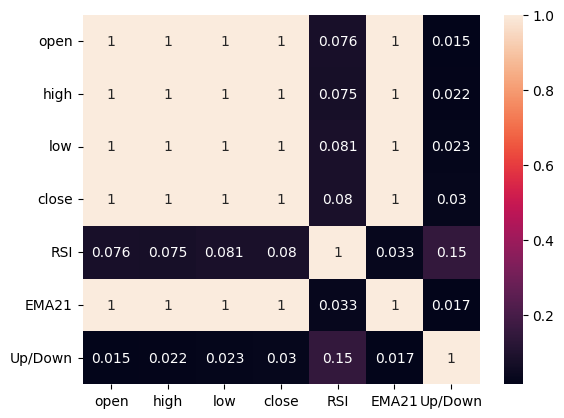

In [18]:
sns.heatmap(data=df_nifty50.corr(), annot=True)

In [19]:
df_ret=df_nifty50['close']
del df_nifty50['open']
del df_nifty50['close']
del df_nifty50['low']
del df_nifty50['high']

<Axes: >

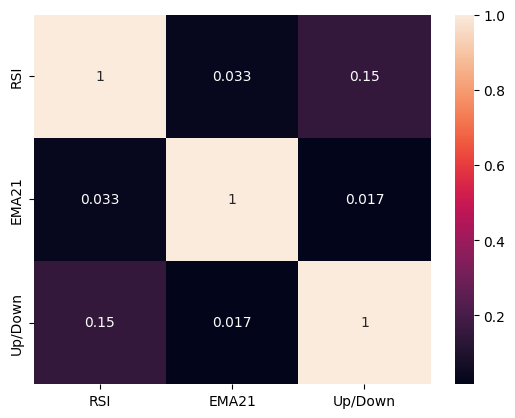

In [20]:
sns.heatmap(data=df_nifty50.corr(), annot=True)

In [21]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
# To plot
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

/tmp/ipykernel_13/3999022765.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


In [22]:
X=df_nifty50.iloc[:,0:-1]
y=df_nifty50.iloc[:,-1]
X

,RSI,EMA21
14,69.833497,8729.500000
15,67.535454,8732.400000
16,70.766715,8741.781818
17,92.353450,8757.119835
18,94.962300,8771.408032
...,...,...
2501,53.601968,23352.144934
2502,59.165076,23387.336304
2503,60.878966,23415.423913
2504,55.830365,23432.508103


In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.5347593582887701

In [24]:
df_nifty50['Predicted_Signal'] = model.predict(X)

In [25]:
df_nifty50['Return'] = df_ret.pct_change()

In [26]:
df_nifty50['Strategy_Return'] = df_nifty50['Return'] *df_nifty50.Predicted_Signal

In [27]:
df_nifty50['Cum_Ret'] = df_nifty50['Return'].cumsum()
df_nifty50

,RSI,EMA21,Up/Down,Predicted_Signal,Return,Strategy_Return,Cum_Ret
14,69.833497,8729.500000,1,1,NaN,NaN,NaN
15,67.535454,8732.400000,1,1,0.003654,0.003654,0.003654
16,70.766715,8741.781818,1,1,0.008469,0.008469,0.012123
17,92.353450,8757.119835,1,1,0.008477,0.008477,0.020600
18,94.962300,8771.408032,1,1,0.000425,0.000425,0.021026
...,...,...,...,...,...,...,...
2501,53.601968,23352.144934,1,0,-0.005157,-0.000000,1.120488
2502,59.165076,23387.336304,1,0,0.016189,0.000000,1.136677
2503,60.878966,23415.423913,0,0,-0.001809,-0.000000,1.134868
2504,55.830365,23432.508103,0,0,-0.003923,-0.000000,1.130945


In [28]:
df_nifty50['Cum_Strategy'] = df_nifty50['Strategy_Return'].cumsum()
df_nifty50

,RSI,EMA21,Up/Down,Predicted_Signal,Return,Strategy_Return,Cum_Ret,Cum_Strategy
14,69.833497,8729.500000,1,1,NaN,NaN,NaN,NaN
15,67.535454,8732.400000,1,1,0.003654,0.003654,0.003654,0.003654
16,70.766715,8741.781818,1,1,0.008469,0.008469,0.012123,0.012123
17,92.353450,8757.119835,1,1,0.008477,0.008477,0.020600,0.020600
18,94.962300,8771.408032,1,1,0.000425,0.000425,0.021026,0.021026
...,...,...,...,...,...,...,...,...
2501,53.601968,23352.144934,1,0,-0.005157,-0.000000,1.120488,2.095315
2502,59.165076,23387.336304,1,0,0.016189,0.000000,1.136677,2.095315
2503,60.878966,23415.423913,0,0,-0.001809,-0.000000,1.134868,2.095315
2504,55.830365,23432.508103,0,0,-0.003923,-0.000000,1.130945,2.095315


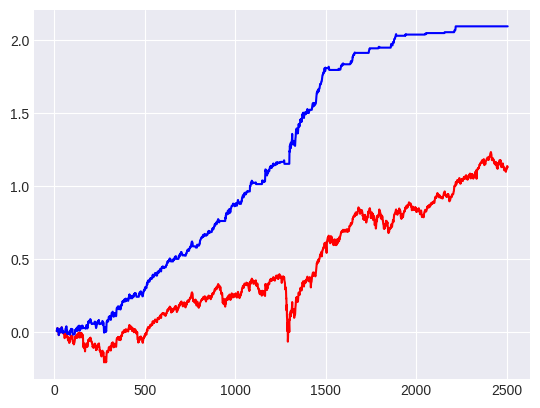

In [29]:
plt.plot(df_nifty50['Cum_Ret'],color='red')
plt.plot(df_nifty50['Cum_Strategy'],color='blue')

In [30]:
df_nifty50['Return'].sum()

1.129106726475103

In [31]:
df_nifty50['Strategy_Return'].sum()

2.0953153559775455